## Portfolio Loss Distribution Simulation & Tranche Analysis (5Y / 10Y)

Two parallel pipelines:
- Pipeline A: EAD = 1.0 (unit / equal-weighted)
- Pipeline B: EAD = `grossapproval` (real dollar amounts, LGD = 0.6)

Both pipelines use:
- Competing-risk TV-Cox (two separate models, each with its own feature set).
    - Default model (10 features): `naicscode_72`, `ifthirdparty`, `borrstate_FL`,
                                   `unemp_m_st`, `naicscode_Unknown`, `t2y_m`,
                                   `naicscode_62`, `naicscode_44`, `tnx_m`, `GDP_growth_y_st`.
    - PayInFull/Prepayment model (10 features): `repeat_borrower`, `collateralind_Unknown`, `vix_m`,
                                                `russell2000_ret_m`, `HPI_growth_m`, `PPI_growth_m`,
                                                `naicscode_62`, `CPI_growth_m`, `GDP_growth_y_st`, `yield_spread_m`.
    - Event coding: 0 = censored, 1 = default, 2 = pay-in-full.
- Tranche analysis: [5%, 15%] mezzanine  and  [15%, 100%] senior.
- Full risk metrics per tranche per horizon (VaR95/99, AVaR95/99).
- Per-loan amortization uses `terminmonths` column from data
$$
B(t) = B0 \cdot [(1+r)^T_i - (1+r)^t] / [(1+r)^T_i - 1],
$$
where $T_i =$ `terminmonths` for loan $i$  (falls back to `LOAN_TERM_MONTHS` if missing).



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lifelines import CoxTimeVaryingFitter
from scipy.stats import binom
from typing import List, Tuple
from tqdm import tqdm

pd.set_option("display.max_columns", None)
RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

In [2]:
# Configs
DATA_TRAIN_VAL = "../data/data_tv_train_val.parquet"
DATA_TEST = "../data/data_tv_test.parquet"
SAVE_DIR = "../figures"

# Simulation settings
NUM_SIMS = 10_000
PORTFOLIO_SIZE = 1_000
LGD = 0.6  # Loss Given Default (Pipeline B only; Pipeline A uses 1.0)
MONTHLY_RATE = 0.0375 / 12  # annual 3.75% (today) -> monthly (used when terminmonths is missing)
LOAN_TERM_MONTHS = 240  # fallback term when terminmonths is NaN
MEZZ_ATTACH, MEZZ_DETACH = 0.05, 0.15
SENIOR_ATTACH, SENIOR_DETACH = 0.15, 1.00

# Feature lists for the two cause-specific models (from the previous section)
TV_FEATURES_DEFAULT = [
    'naicscode_72', 'ifthirdparty', 'borrstate_FL', 'unemp_m_st',
    'naicscode_Unknown', 't2y_m', 'naicscode_62', 'naicscode_44',
    'tnx_m', 'GDP_growth_y_st'
]
TV_FEATURES_PREPAY = [
    'repeat_borrower', 'collateralind_Unknown', 'vix_m', 'russell2000_ret_m',
    'HPI_growth_m', 'PPI_growth_m', 'naicscode_62', 'CPI_growth_m',
    'GDP_growth_y_st', 'yield_spread_m'
]

# Union of all feature columns needed in the portfolio / test set
TV_ALL_FEATURES = sorted(set(TV_FEATURES_DEFAULT) | set(TV_FEATURES_PREPAY))
TV_MACRO_COLS = [
    "GDP_y_st", "GDP_growth_y_st", "CPI_m", "CPI_growth_m",
    "crime_rate_m_st", "crime_rate_growth_m_st", "EHE_m_st",
    "EHE_growth_m_st", "HPI_m", "HPI_growth_m", "PPI_m", "PPI_growth_m",
    "unemp_m_st", "unemp_growth_m_st", "sp500_ret_m", "vix_m", "tnx_m",
    "t2y_m", "russell2000_ret_m", "yield_spread_m",
]

In [3]:
# 1) data preparation helper
def _prepare_tv_df(df, feature_cols, fill_map=None, event_col="event_t"):
    """
    Prepare a long-format TV-Cox dataframe.
    """
    x = df.copy()
    x[event_col] = x[event_col].fillna(0).astype(int)
    x = x.dropna(subset=["loan_id", "month_start", "month_stop"])
    x = x[x["month_stop"] > x["month_start"]].copy()

    # terminmonths: numeric, fill with global fallback
    if "terminmonths" in x.columns:
        x["terminmonths"] = x["terminmonths"].fillna(LOAN_TERM_MONTHS)
    else:
        x["terminmonths"] = float(LOAN_TERM_MONTHS)

    use_cols = [c for c in feature_cols if c in x.columns]
    if fill_map is None:
        fill_map = {c: x[c].median() for c in use_cols}
    for c in use_cols:
        x[c] = x[c].fillna(fill_map[c])
    for c in feature_cols:
        if c not in x.columns:
            x[c] = fill_map.get(c, 0.0)

    extra = ["loan_id", "month_start", "month_stop", event_col, "grossapproval", "terminmonths"]
    keep = extra + [c for c in feature_cols if c not in extra]
    
    return x[keep].copy(), fill_map

In [4]:
# 2) Load data & fit both Cox models
def load_and_fit_models():
    """
    Fit two cause-specific TV-Cox models with their own feature sets
    """
    print("Loading data ...")
    df_train = pd.read_parquet(DATA_TRAIN_VAL)
    df_test = pd.read_parquet(DATA_TEST)

    # Default model
    df_train_d = df_train.copy()
    df_train_d["event_t"] = (pd.to_numeric(df_train_d["event_t"], errors="coerce").fillna(0) == 1).astype(int)
    train_def, fill_map_d = _prepare_tv_df(df_train_d, TV_FEATURES_DEFAULT, event_col="event_t")

    print("\nFitting DEFAULT TV-Cox model ...")
    ctv_default = CoxTimeVaryingFitter(penalizer=0.01)
    ctv_default.fit(
        train_def.drop(columns=["grossapproval", "terminmonths"]),
        id_col="loan_id", start_col="month_start",
        stop_col="month_stop", event_col="event_t",
        show_progress=True
    )

    h0_d = ctv_default.baseline_cumulative_hazard_
    h0d_s = (h0_d.iloc[:, 0].astype(float) if isinstance(h0_d, pd.DataFrame) else h0_d.astype(float))
    h0d_t = h0d_s.index.to_numpy(dtype=float)
    h0d_v = h0d_s.to_numpy(dtype=float)

    # Prepayment model
    df_train_p = df_train.copy()
    df_train_p["event_prepay"] = (pd.to_numeric(df_train_p["event_t"], errors="coerce").fillna(0) == 2).astype(int)
    train_pre, fill_map_p = _prepare_tv_df(df_train_p, TV_FEATURES_PREPAY, event_col="event_prepay")

    print("\nFitting PREPAYMENT TV-Cox model ...")
    ctv_prepay = CoxTimeVaryingFitter(penalizer=0.01)
    ctv_prepay.fit(
        train_pre.drop(columns=["grossapproval", "terminmonths"]),
        id_col="loan_id", start_col="month_start",
        stop_col="month_stop", event_col="event_prepay",
        show_progress=True
    )

    h0_p = ctv_prepay.baseline_cumulative_hazard_
    h0p_s = (h0_p.iloc[:, 0].astype(float) if isinstance(h0_p, pd.DataFrame) else h0_p.astype(float))
    h0p_t = h0p_s.index.to_numpy(dtype=float)
    h0p_v = h0p_s.to_numpy(dtype=float)

    # Test set: keep ALL features needed by either model
    combined_fill = {**fill_map_p, **fill_map_d}
    test_tv, _ = _prepare_tv_df( df_test, TV_ALL_FEATURES, fill_map=combined_fill, event_col="event_t")

    print(f"\nTrain rows (default) : {len(train_def):,}  |  loans : {train_def['loan_id'].nunique():,}")
    print(f"Train rows (prepay)  : {len(train_pre):,}  |  loans : {train_pre['loan_id'].nunique():,}")

    return ctv_default, ctv_prepay, h0d_t, h0d_v, h0p_t, h0p_v, combined_fill, test_tv

In [5]:
# 3) Build the portfolio
def build_portfolio(test_tv, seed=RANDOM_SEED, n=PORTFOLIO_SIZE):
    """
    Take the most recent snapshot of each loan from the test set.
    """
    latest_by_loan = test_tv.sort_values(["loan_id", "month_stop"]).groupby("loan_id", as_index=False).tail(1).reset_index(drop=True)
    latest_month = test_tv["month_stop"].max()
    current_slice = test_tv.loc[test_tv["month_stop"] == latest_month]

    # Freeze macro covariates at the latest observed month
    macro_present = [c for c in TV_MACRO_COLS if c in TV_ALL_FEATURES and c in current_slice.columns]
    current_macro = (current_slice[macro_present].median() if macro_present else pd.Series(dtype=float))

    portfolio = latest_by_loan.copy()
    for c in macro_present:
        portfolio[c] = current_macro[c]
    replace_flag = len(portfolio) < n
    portfolio = portfolio.sample(n=n, replace=replace_flag, random_state=seed).reset_index(drop=True)

    print(f"\nAvailable test loans : {latest_by_loan.shape[0]:,}")
    print(f"Portfolio size       : {portfolio.shape[0]:,}  (with_replacement={replace_flag})")
    print(f"Latest month_stop    : {latest_month}")

    return portfolio

In [6]:
# 4) Helpers
def make_H0_interp(h0_t, h0_v):
    def H0_interp(t):
        t = np.asarray(t, dtype=float)
        return np.interp(t, h0_t, h0_v, left=0.0, right=h0_v[-1])
    return H0_interp

def remaining_balance_factors(t: np.ndarray,
                              T: np.ndarray,
                              r: float = MONTHLY_RATE) -> np.ndarray:
    """
    Per-loan standard fixed-payment amortization.

    Parameters
    ----------
    t : months elapsed since simulation start, per loan  (1-D array)
    T : loan term in months, per loan                    (1-D array, same length)
    r : monthly interest rate (scalar, shared)

    Returns
    -------
    factor : B(t) / B(0) for each loan, clipped to [0, 1]
    """
    t = np.asarray(t, dtype=float)
    T = np.asarray(T, dtype=float)
    if r == 0:
        return np.clip(1.0 - t / T, 0.0, 1.0)
    rT = (1.0 + r) ** T   # per-loan (1+r)^T_i
    rt = (1.0 + r) ** t   # per-loan (1+r)^t
    factor = (rT - rt) / (rT - 1.0)
    
    return np.clip(factor, 0.0, 1.0)

def update_covariates(survived_loans):
    """Advance time by one month for surviving loans."""
    df = survived_loans.copy()
    df["month_stop"]  = df["month_stop"] + 1
    df["months_elapsed"] = df["months_elapsed"] + 1

    return df

In [7]:
# 5) Competing-risk prediction
def get_survival_preds(sim_df, ctv_default, ctv_prepay, H0d_interp, H0p_interp, horizon_months: int = 1):
    """
    Cause-specific TV-Cox competing risks.
    """
    age = sim_df["month_stop"].to_numpy(dtype=float)

    # Default
    x_d = sim_df[TV_FEATURES_DEFAULT].to_numpy(dtype=float)
    beta_d = ctv_default.params_.reindex(TV_FEATURES_DEFAULT).to_numpy(dtype=float)
    hr_d = np.exp(x_d @ beta_d)
    dH_d = np.clip(H0d_interp(age + horizon_months) - H0d_interp(age), 0.0, None)
    p_default = np.clip(1.0 - np.exp(-dH_d * hr_d), 0.0, 1.0)

    # Prepayment
    x_p = sim_df[TV_FEATURES_PREPAY].to_numpy(dtype=float)
    beta_p = ctv_prepay.params_.reindex(TV_FEATURES_PREPAY).to_numpy(dtype=float)
    hr_p = np.exp(x_p @ beta_p)
    dH_p = np.clip(H0p_interp(age + horizon_months) - H0p_interp(age), 0.0, None)
    p_prepay = np.clip(1.0 - np.exp(-dH_p * hr_p), 0.0, 1.0)

    # Normalize so p_D + p_P <= 1
    total = p_default + p_prepay
    overflow = total > 1.0
    if overflow.any():
        scale = 1.0 / total[overflow]
        p_default[overflow] *= scale
        p_prepay[overflow] *= scale

    p_survive = 1.0 - p_default - p_prepay

    return pd.Series(p_survive, index=sim_df.index), pd.Series(p_prepay, index=sim_df.index), pd.Series(p_default, index=sim_df.index)

In [8]:
# 6) Compute VaR / AVaR / CI
def calculate_var(losses: List[float], confidence_level: float) -> float:
    """VaR as a positive loss number (losses are negative = worse)."""
    if not 0.0 < confidence_level < 1.0:
        raise ValueError("confidence_level must be in (0, 1).")
    x = np.asarray(losses, dtype=float)
    if x.size == 0:
        raise ValueError("losses must be non-empty.")
    q = float(np.quantile(x, 1 - confidence_level, method="higher"))
    
    return -q

def calculate_avar(losses: List[float], confidence_level: float) -> float:
    """AVaR / ES as a positive loss number."""
    if not 0.0 < confidence_level < 1.0:
        raise ValueError("confidence_level must be in (0, 1).")
    x = np.asarray(losses, dtype=float)
    if x.size == 0:
        raise ValueError("losses must be non-empty.")
    q = float(np.quantile(x, 1 - confidence_level, method="lower"))
    tail = x[x <= q]
    if tail.size == 0:
        tail = np.array([q], dtype=float)

    return -float(tail.mean())

def calculate_var_ci(losses: List[float], confidence_level: float = 0.95) -> Tuple[float, float]:
    """Binomial confidence interval for the VaR estimate."""
    r = sorted(losses)
    n = len(r)
    kappa = 1.0 - confidence_level
    coverage = confidence_level
    m = max(1, min(n, int(round((n + 1) * kappa))))
    for w in range(n):
        lo = max(1, m - w)
        hi = min(n, m + w)
        if binom.cdf(hi - 1, n, kappa) - binom.cdf(lo - 1, n, kappa) >= coverage:
            return (-r[hi - 1], -r[lo - 1])

    return (-r[-1], -r[0])

In [9]:
# 7) Core simulation
def run_simulation(portfolio_ead, ctv_default, ctv_prepay, H0d_interp, H0p_interp,
                   horizon_years: int, num_simulations: int, lgd: float) -> List[float]:
    """
    Monte Carlo simulation:
      for each simulation run:
        for each monthly step:
          1. update EAD via per-loan amortization: B_i(t) = EAD_i * factor(t, T_i)
          2. get competing-risk probabilities: p_default, p_prepay, p_survive
          3. draw u ~ Uniform(0, p_survive+p_prepay+p_default) [sums to 1]
          4. chargeoff: if u < p_default
             payinfull: if p_default <= u < p_default + p_prepay (no loss)
             survive: otherwise
          5. loss += EAD_i(t) * LGD for charged-off loans
          6. update_covariates for survivors (month_stop +1, months_elapsed +1)
    """
    n_steps = horizon_years * 12
    losses: List[float] = []

    for _ in tqdm(range(num_simulations), desc=f"Simulating {horizon_years}Y ..."):
        sim_df = portfolio_ead.copy()
        sim_df["EAD_original"] = sim_df["EAD"]
        sim_df["months_elapsed"] = 0
        loss_total = 0.0

        for _ in range(n_steps):
            if sim_df.empty:
                break

            # 1. Per-loan amortization: B_i(t)
            t = sim_df["months_elapsed"].to_numpy(dtype=float)
            T_loan = sim_df["terminmonths"].to_numpy(dtype=float)
            factor = remaining_balance_factors(t, T_loan)
            sim_df["EAD"] = sim_df["EAD_original"] * factor

            # 2. Competing-risk probabilities
            p_survive, p_prepay, p_default = get_survival_preds(sim_df, ctv_default, ctv_prepay, H0d_interp, H0p_interp)

            # 3. Draw outcomes  (upper bound = 1.0 since probabilities are normalized)
            u = pd.Series(np.random.uniform(0, p_survive + p_prepay + p_default, size=len(sim_df)), index=sim_df.index)
            chargeoff_mask = u < p_default
            survived_mask = u >= (p_default + p_prepay)

            # 4. Accumulate chargeoff losses
            if chargeoff_mask.any():
                defaulted = sim_df.loc[chargeoff_mask]
                loss_total -= float((defaulted["EAD"].to_numpy(dtype=float) * lgd).sum())

            # 5. Advance surviving loans
            sim_df = update_covariates(sim_df.loc[survived_mask].copy())

        losses.append(loss_total)

    return losses

In [10]:
# 8) Tranche mechanics
def tranche_loss_rate(portfolio_loss_rate: np.ndarray, attach: float, detach: float) -> np.ndarray:
    """Map portfolio loss rate -> tranche loss rate."""
    width = detach - attach
    absorbed = np.clip(portfolio_loss_rate - attach, 0.0, width)
    
    return absorbed / width

def risk_metrics(tranche_lr: np.ndarray, label: str) -> dict:
    """Compute and print risk metrics for a tranche loss-rate series."""
    signed = -tranche_lr
    var95 = calculate_var(list(signed), 0.95)
    var99 = calculate_var(list(signed), 0.99)
    avar95 = calculate_avar(list(signed), 0.95)
    avar99 = calculate_avar(list(signed), 0.99)
    ci_lo, ci_hi = calculate_var_ci(list(signed), 0.95)

    metrics = {
        "Mean loss rate" : tranche_lr.mean(),
        "Std" : tranche_lr.std(ddof=1),
        "P(any loss)" : (tranche_lr > 0).mean(),
        "P(wiped out)" : (tranche_lr >= 1.0).mean(),
        "P50" : np.quantile(tranche_lr, 0.50),
        "P90" : np.quantile(tranche_lr, 0.90),
        "VaR 95%" : var95,
        "VaR 99%" : var99,
        "AVaR 95%" : avar95,
        "AVaR 99%" : avar99,
        "VaR 95% CI" : f"[{ci_lo:.4f}, {ci_hi:.4f}]",
    }

    print(f"\n{'='*55}")
    print(f"  {label}")
    print(f"{'='*55}")
    for k, v in metrics.items():
        print(f"  {k:<20s}: {v:.4f}" if isinstance(v, float) else
              f"  {k:<20s}: {v}")

    return metrics

In [11]:
# 9) Plotting helpers
def plot_portfolio_hist(port_lr: np.ndarray, tag: str, pipeline_name: str, num_sims: int):
    var95 = calculate_var(list(-port_lr), 0.95)
    avar95 = calculate_avar(list(-port_lr), 0.95)
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.hist(port_lr, bins=50, edgecolor="k", alpha=0.8, color="steelblue")
    ax.axvline(var95, color="r", linestyle="--", label=f"VaR 95%: {var95:.4f}")
    ax.axvline(avar95, color="g", linestyle="--", label=f"AVaR 95%: {avar95:.4f}")
    ax.set_xlabel("Portfolio loss rate")
    ax.set_ylabel("Frequency")
    ax.set_title(f"[{pipeline_name}] Portfolio Loss Rate ({tag}, N={num_sims:,})")
    ax.legend()
    plt.tight_layout()
    fname = f"{SAVE_DIR}/portfolio_loss_{tag}_{pipeline_name}.png"
    plt.savefig(fname, dpi=150)
    plt.show()
    print(f"Saved: {fname}")

def plot_tranche_comparison(results: dict, pipeline_name: str):
    horizons = ["5Y", "10Y"]
    tranches = [("portfolio_lr", "Portfolio", "steelblue"),
                ("mezz_lr", "[5%-15%] Mezz", "darkorange"),
                ("senior_lr", "[15%-100%] Senior", "seagreen")]
    fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharey=False)
    fig.suptitle(f"[{pipeline_name}] Loss Rate Distributions: Portfolio vs Tranches", fontsize=13, fontweight="bold")
    for row, horizon in enumerate(horizons):
        data = results[horizon]
        for col, (key, label, color) in enumerate(tranches):
            ax = axes[row, col]
            arr = data[key]
            v95 = float(np.quantile(arr, 0.95))
            av95 = float(arr[arr >= v95].mean()) if (arr >= v95).any() else v95
            ax.hist(arr, bins=60, color=color, alpha=0.75, edgecolor="white", linewidth=0.3)
            ax.axvline(v95, color="red", linestyle="--", lw=1.5, label=f"VaR 95%={v95:.3f}")
            ax.axvline(av95, color="crimson", linestyle=":", lw=1.5, label=f"AVaR 95%={av95:.3f}")
            ax.set_title(f"{horizon} - {label}", fontsize=10)
            ax.set_xlabel("Loss rate")
            ax.set_ylabel("Frequency" if col == 0 else "")
            ax.legend(fontsize=7)
            ax.grid(alpha=0.2)
    plt.tight_layout()
    fname = f"{SAVE_DIR}/tranche_distributions_{pipeline_name}.png"
    plt.savefig(fname, dpi=150)
    plt.show()
    print(f"Saved: {fname}")

def plot_loss_rate_cdf(results: dict, pipeline_name: str):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"[{pipeline_name}] CDF of Loss Rates",
                 fontsize=13, fontweight="bold")
    styles = [("portfolio_lr", "Portfolio", "steelblue", "-"),
              ("mezz_lr", "[5%-15%] Mezz", "darkorange", "--"),
              ("senior_lr", "[15%-100%] Senior", "seagreen", ":")]
    for ax, horizon in zip(axes, ["5Y", "10Y"]):
        data = results[horizon]
        for key, label, color, ls in styles:
            arr = np.sort(data[key])
            cdf = np.arange(1, len(arr) + 1) / len(arr)
            ax.plot(arr, cdf, color=color, linestyle=ls, lw=2, label=label)
        ax.axhline(0.95, color="grey", linestyle="--", lw=0.8, alpha=0.6, label="95th pct")
        ax.set_xlabel("Loss rate")
        ax.set_ylabel("CDF")
        ax.set_title(f"{horizon} Horizon")
        ax.legend(fontsize=9)
        ax.grid(alpha=0.2)
    plt.tight_layout()
    fname = f"{SAVE_DIR}/tranche_cdf_{pipeline_name}.png"
    plt.savefig(fname, dpi=150)
    plt.show()
    print(f"Saved: {fname}")

def plot_summary_bar(all_metrics: dict, pipeline_name: str):
    labels = ["Portfolio\n5Y", "Mezz [5-15%]\n5Y", "Senior [15-100%]\n5Y",
              "Portfolio\n10Y", "Mezz [5-15%]\n10Y", "Senior [15-100%]\n10Y"]
    var_vals  = [all_metrics[k]["VaR 95%"]  for k in labels]
    avar_vals = [all_metrics[k]["AVaR 95%"] for k in labels]
    x = np.arange(len(labels))
    w = 0.35
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.bar(x - w/2, var_vals, w, label="VaR 95%", color="steelblue", alpha=0.85)
    ax.bar(x + w/2, avar_vals, w, label="AVaR 95%", color="darkorange", alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=9)
    ax.set_ylabel("Loss rate")
    ax.set_title(f"[{pipeline_name}] VaR 95% and AVaR 95% by Tranche and Horizon")
    ax.legend()
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    fname = f"{SAVE_DIR}/tranche_var_comparison_{pipeline_name}.png"
    plt.savefig(fname, dpi=150)
    plt.show()
    print(f"Saved: {fname}")

In [12]:
# A full pipeline
def run_pipeline(portfolio_base, ctv_default, ctv_prepay, H0d_interp, H0p_interp, ead_mode: str):
    """
    ead_mode = "unit"   -> EAD = 1.0, LGD = 1.0
    ead_mode = "dollar" -> EAD = grossapproval, LGD = 0.6
    """
    assert ead_mode in ("unit", "dollar")
    pipeline_name = "EAD=1" if ead_mode == "unit" else "EAD=grossapproval_LGD0.6"

    print(f"\n{'#'*70}")
    print(f"#  PIPELINE: {pipeline_name}")
    print(f"{'#'*70}")

    portfolio = portfolio_base.copy()
    if ead_mode == "unit":
        portfolio["EAD"] = 1.0
        lgd = 1.0
        total_notional = float(len(portfolio))
    else:
        portfolio["EAD"] = portfolio["grossapproval"].to_numpy(dtype=float)
        lgd = LGD
        total_notional = portfolio["EAD"].sum()

    print(f"Total notional : {total_notional:,.2f}")

    results = {}
    all_metrics = {}

    for horizon in [5, 10]:
        tag = f"{horizon}Y"
        print(f"\n{'='*60}")
        print(f"  HORIZON: {tag}")
        print(f"{'='*60}")

        losses = run_simulation(
            portfolio, ctv_default, ctv_prepay,
            H0d_interp, H0p_interp,
            horizon_years=horizon,
            num_simulations=NUM_SIMS,
            lgd=lgd
        )

        port_lr = np.array([-l for l in losses]) / total_notional
        mezz_lr = tranche_loss_rate(port_lr, MEZZ_ATTACH, MEZZ_DETACH)
        senior_lr = tranche_loss_rate(port_lr, SENIOR_ATTACH, SENIOR_DETACH)

        results[tag] = {
            "portfolio_lr": port_lr,
            "mezz_lr"     : mezz_lr,
            "senior_lr"   : senior_lr,
        }

        for lr, label_key in [
            (port_lr, f"Portfolio\n{tag}"),
            (mezz_lr, f"Mezz [5-15%]\n{tag}"),
            (senior_lr, f"Senior [15-100%]\n{tag}"),
        ]:
            m = risk_metrics(lr, label_key)
            all_metrics[label_key] = m

        plot_portfolio_hist(port_lr, tag, pipeline_name, NUM_SIMS)

    plot_tranche_comparison(results, pipeline_name)
    plot_loss_rate_cdf(results, pipeline_name)
    plot_summary_bar(all_metrics, pipeline_name)

    rows = []
    for k, m in all_metrics.items():
        row = {"Tranche / Horizon": k.replace("\n", " ")}
        row.update({kk: vv for kk, vv in m.items() if kk != "VaR 95% CI"})
        rows.append(row)
    summary = pd.DataFrame(rows).set_index("Tranche / Horizon")

    print(f"\n\n{'='*70}")
    print(f"RISK METRICS SUMMARY  [{pipeline_name}]")
    print(f"{'='*70}")
    print(summary.to_string(float_format="{:.4f}".format))

    csv_name = f"{SAVE_DIR}/tranche_risk_summary_{pipeline_name}.csv"
    summary.to_csv(csv_name)
    print(f"\nSaved: {csv_name}")
    return summary

In [13]:
# 11) Main function
def main():
    # Fit both models
    ctv_default, ctv_prepay, h0d_t, h0d_v, h0p_t, h0p_v, combined_fill, test_tv = load_and_fit_models()
    H0d_interp = make_H0_interp(h0d_t, h0d_v)
    H0p_interp = make_H0_interp(h0p_t, h0p_v)

    # Build portfolio (shared base for both pipelines)
    portfolio_base = build_portfolio(test_tv)

    # Pipeline A: EAD = 1 (unit)
    summary_unit = run_pipeline(
        portfolio_base, ctv_default, ctv_prepay,
        H0d_interp, H0p_interp,
        ead_mode="unit"
    )

    # Pipeline B: EAD = grossapproval, LGD = 0.6
    summary_dollar = run_pipeline(
        portfolio_base, ctv_default, ctv_prepay,
        H0d_interp, H0p_interp,
        ead_mode="dollar"
    )

    # Side-by-side final comparison
    print("\n\n" + "=" * 70)
    print("FINAL COMPARISON: EAD=1  vs  EAD=grossapproval")
    print("=" * 70)
    comp = pd.concat([summary_unit.add_suffix(" [unit]"), summary_dollar.add_suffix(" [dollar]")], axis=1)
    print(comp.to_string(float_format="{:.4f}".format))
    comp.to_csv(f"{SAVE_DIR}/comparison_unit_vs_dollar.csv")
    print("\nSaved: comparison_unit_vs_dollar.csv")

Loading data ...

Fitting DEFAULT TV-Cox model ...
Iteration 1: norm_delta = 7.75e-02, step_size = 0.9500, log_lik = -132349.99898, newton_decrement = 5.52e+02, seconds_since_start = 22.8
Iteration 2: norm_delta = 3.79e-03, step_size = 0.9500, log_lik = -131799.25950, newton_decrement = 1.33e+00, seconds_since_start = 46.1
Iteration 3: norm_delta = 1.89e-04, step_size = 0.9500, log_lik = -131797.93643, newton_decrement = 3.31e-03, seconds_since_start = 69.0
Iteration 4: norm_delta = 9.96e-06, step_size = 1.0000, log_lik = -131797.93312, newton_decrement = 8.29e-06, seconds_since_start = 92.2
Iteration 5: norm_delta = 4.45e-12, step_size = 1.0000, log_lik = -131797.93311, newton_decrement = 1.56e-18, seconds_since_start = 114.8
Convergence completed after 5 iterations.

Fitting PREPAYMENT TV-Cox model ...
Iteration 1: norm_delta = 2.20e-01, step_size = 0.9500, log_lik = -1070758.20114, newton_decrement = 6.38e+03, seconds_since_start = 25.4
Iteration 2: norm_delta = 3.14e-02, step_size 

Simulating 5Y ...: 100%|██████████| 10000/10000 [47:54<00:00,  3.48it/s]



  Portfolio
5Y
  Mean loss rate      : 0.0443
  Std                 : 0.0062
  P(any loss)         : 1.0000
  P(wiped out)        : 0.0000
  P50                 : 0.0443
  P90                 : 0.0524
  VaR 95%             : 0.0547
  VaR 99%             : 0.0590
  AVaR 95%            : 0.0575
  AVaR 99%            : 0.0613
  VaR 95% CI          : [0.0545, 0.0551]

  Mezz [5-15%]
5Y
  Mean loss rate      : 0.0064
  Std                 : 0.0185
  P(any loss)         : 0.1777
  P(wiped out)        : 0.0000
  P50                 : 0.0000
  P90                 : 0.0241
  VaR 95%             : 0.0472
  VaR 99%             : 0.0904
  AVaR 95%            : 0.0747
  AVaR 99%            : 0.1132
  VaR 95% CI          : [0.0451, 0.0506]

  Senior [15-100%]
5Y
  Mean loss rate      : 0.0000
  Std                 : 0.0000
  P(any loss)         : 0.0000
  P(wiped out)        : 0.0000
  P50                 : 0.0000
  P90                 : 0.0000
  VaR 95%             : 0.0000
  VaR 99%             :

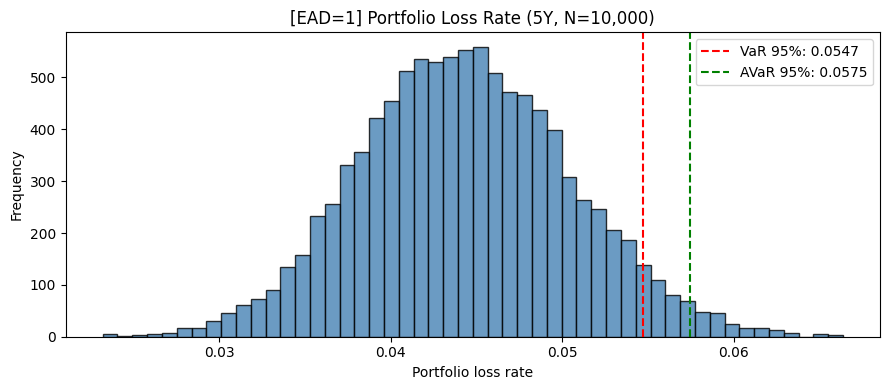

Saved: ../figures/portfolio_loss_5Y_EAD=1.png

  HORIZON: 10Y


Simulating 10Y ...: 100%|██████████| 10000/10000 [1:28:17<00:00,  1.89it/s]



  Portfolio
10Y
  Mean loss rate      : 0.0619
  Std                 : 0.0072
  P(any loss)         : 1.0000
  P(wiped out)        : 0.0000
  P50                 : 0.0617
  P90                 : 0.0713
  VaR 95%             : 0.0739
  VaR 99%             : 0.0791
  AVaR 95%            : 0.0771
  AVaR 99%            : 0.0817
  VaR 95% CI          : [0.0736, 0.0743]

  Mezz [5-15%]
10Y
  Mean loss rate      : 0.1200
  Std                 : 0.0697
  P(any loss)         : 0.9565
  P(wiped out)        : 0.0000
  P50                 : 0.1168
  P90                 : 0.2125
  VaR 95%             : 0.2393
  VaR 99%             : 0.2912
  AVaR 95%            : 0.2715
  AVaR 99%            : 0.3174
  VaR 95% CI          : [0.2357, 0.2429]

  Senior [15-100%]
10Y
  Mean loss rate      : 0.0000
  Std                 : 0.0000
  P(any loss)         : 0.0000
  P(wiped out)        : 0.0000
  P50                 : 0.0000
  P90                 : 0.0000
  VaR 95%             : 0.0000
  VaR 99%           

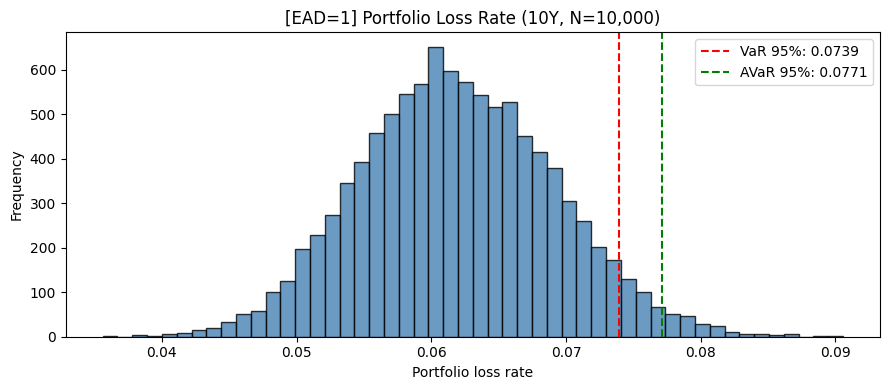

Saved: ../figures/portfolio_loss_10Y_EAD=1.png


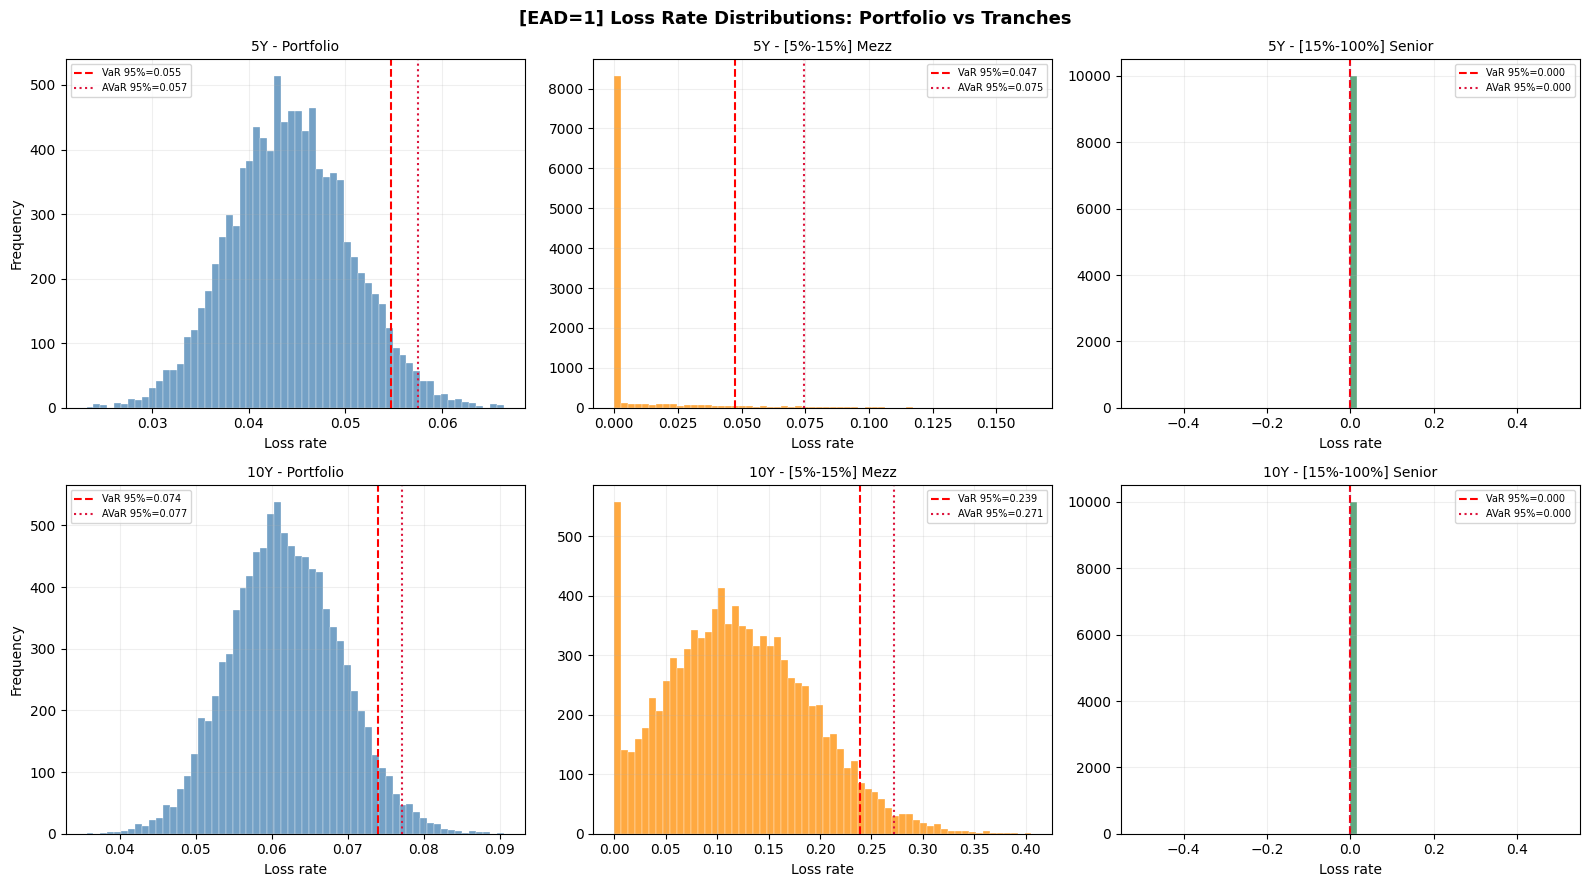

Saved: ../figures/tranche_distributions_EAD=1.png


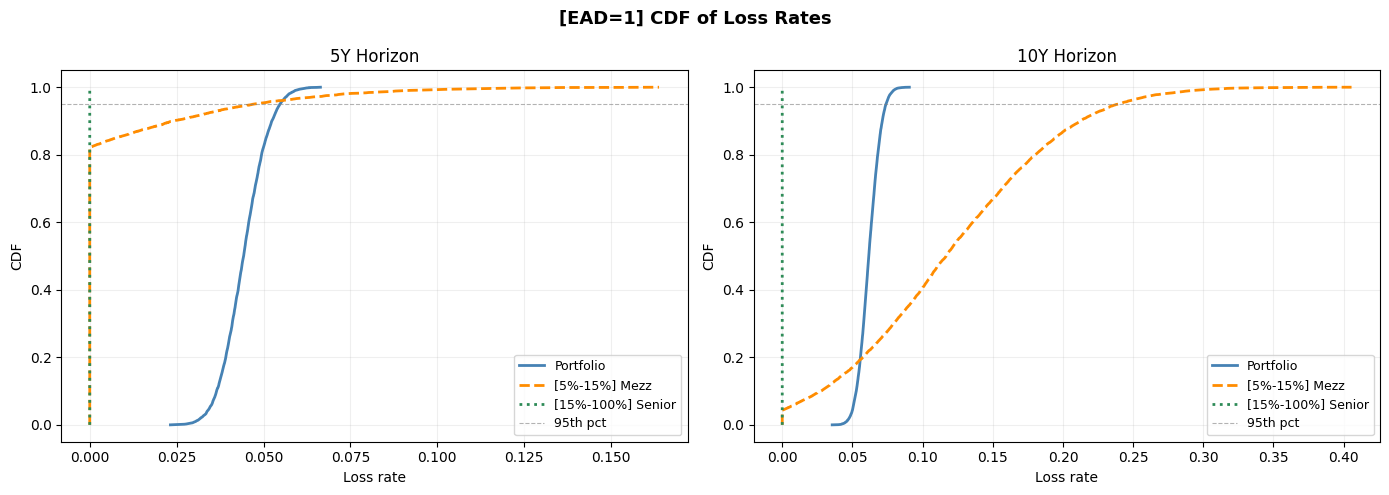

Saved: ../figures/tranche_cdf_EAD=1.png


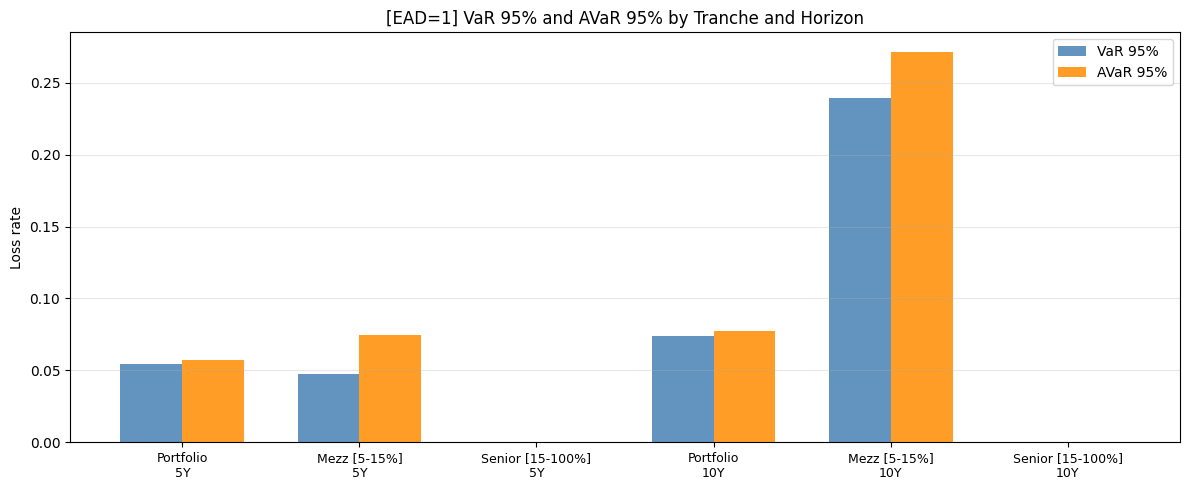

Saved: ../figures/tranche_var_comparison_EAD=1.png


RISK METRICS SUMMARY  [EAD=1]
                      Mean loss rate    Std  P(any loss)  P(wiped out)    P50    P90  VaR 95%  VaR 99%  AVaR 95%  AVaR 99%
Tranche / Horizon                                                                                                         
Portfolio 5Y                  0.0443 0.0062       1.0000        0.0000 0.0443 0.0524   0.0547   0.0590    0.0575    0.0613
Mezz [5-15%] 5Y               0.0064 0.0185       0.1777        0.0000 0.0000 0.0241   0.0472   0.0904    0.0747    0.1132
Senior [15-100%] 5Y           0.0000 0.0000       0.0000        0.0000 0.0000 0.0000   0.0000   0.0000   -0.0000   -0.0000
Portfolio 10Y                 0.0619 0.0072       1.0000        0.0000 0.0617 0.0713   0.0739   0.0791    0.0771    0.0817
Mezz [5-15%] 10Y              0.1200 0.0697       0.9565        0.0000 0.1168 0.2125   0.2393   0.2912    0.2715    0.3174
Senior [15-100%] 10Y          0.0000 0.0000       0.0000

Simulating 5Y ...: 100%|██████████| 10000/10000 [44:53<00:00,  3.71it/s]



  Portfolio
5Y
  Mean loss rate      : 0.0275
  Std                 : 0.0056
  P(any loss)         : 1.0000
  P(wiped out)        : 0.0000
  P50                 : 0.0272
  P90                 : 0.0348
  VaR 95%             : 0.0369
  VaR 99%             : 0.0415
  AVaR 95%            : 0.0398
  AVaR 99%            : 0.0440
  VaR 95% CI          : [0.0367, 0.0372]

  Mezz [5-15%]
5Y
  Mean loss rate      : 0.0000
  Std                 : 0.0003
  P(any loss)         : 0.0002
  P(wiped out)        : 0.0000
  P50                 : 0.0000
  P90                 : 0.0000
  VaR 95%             : 0.0000
  VaR 99%             : 0.0000
  AVaR 95%            : 0.0000
  AVaR 99%            : 0.0000
  VaR 95% CI          : [0.0000, 0.0000]

  Senior [15-100%]
5Y
  Mean loss rate      : 0.0000
  Std                 : 0.0000
  P(any loss)         : 0.0000
  P(wiped out)        : 0.0000
  P50                 : 0.0000
  P90                 : 0.0000
  VaR 95%             : 0.0000
  VaR 99%             :

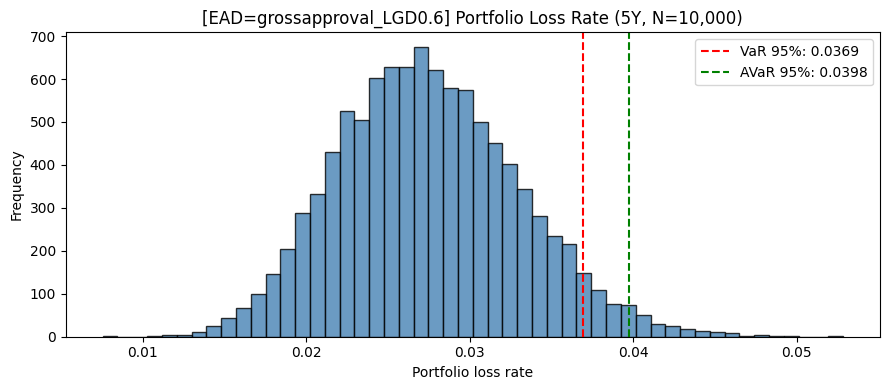

Saved: ../figures/portfolio_loss_5Y_EAD=grossapproval_LGD0.6.png

  HORIZON: 10Y


Simulating 10Y ...: 100%|██████████| 10000/10000 [1:18:13<00:00,  2.13it/s]



  Portfolio
10Y
  Mean loss rate      : 0.0385
  Std                 : 0.0063
  P(any loss)         : 1.0000
  P(wiped out)        : 0.0000
  P50                 : 0.0383
  P90                 : 0.0467
  VaR 95%             : 0.0493
  VaR 99%             : 0.0539
  AVaR 95%            : 0.0522
  AVaR 99%            : 0.0563
  VaR 95% CI          : [0.0490, 0.0497]

  Mezz [5-15%]
10Y
  Mean loss rate      : 0.0011
  Std                 : 0.0074
  P(any loss)         : 0.0412
  P(wiped out)        : 0.0000
  P50                 : 0.0000
  P90                 : 0.0000
  VaR 95%             : 0.0000
  VaR 99%             : 0.0386
  AVaR 95%            : 0.0011
  AVaR 99%            : 0.0634
  VaR 95% CI          : [0.0000, 0.0000]

  Senior [15-100%]
10Y
  Mean loss rate      : 0.0000
  Std                 : 0.0000
  P(any loss)         : 0.0000
  P(wiped out)        : 0.0000
  P50                 : 0.0000
  P90                 : 0.0000
  VaR 95%             : 0.0000
  VaR 99%           

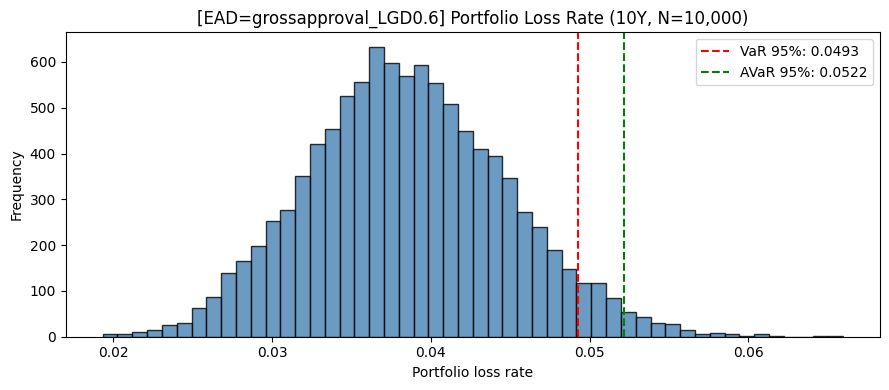

Saved: ../figures/portfolio_loss_10Y_EAD=grossapproval_LGD0.6.png


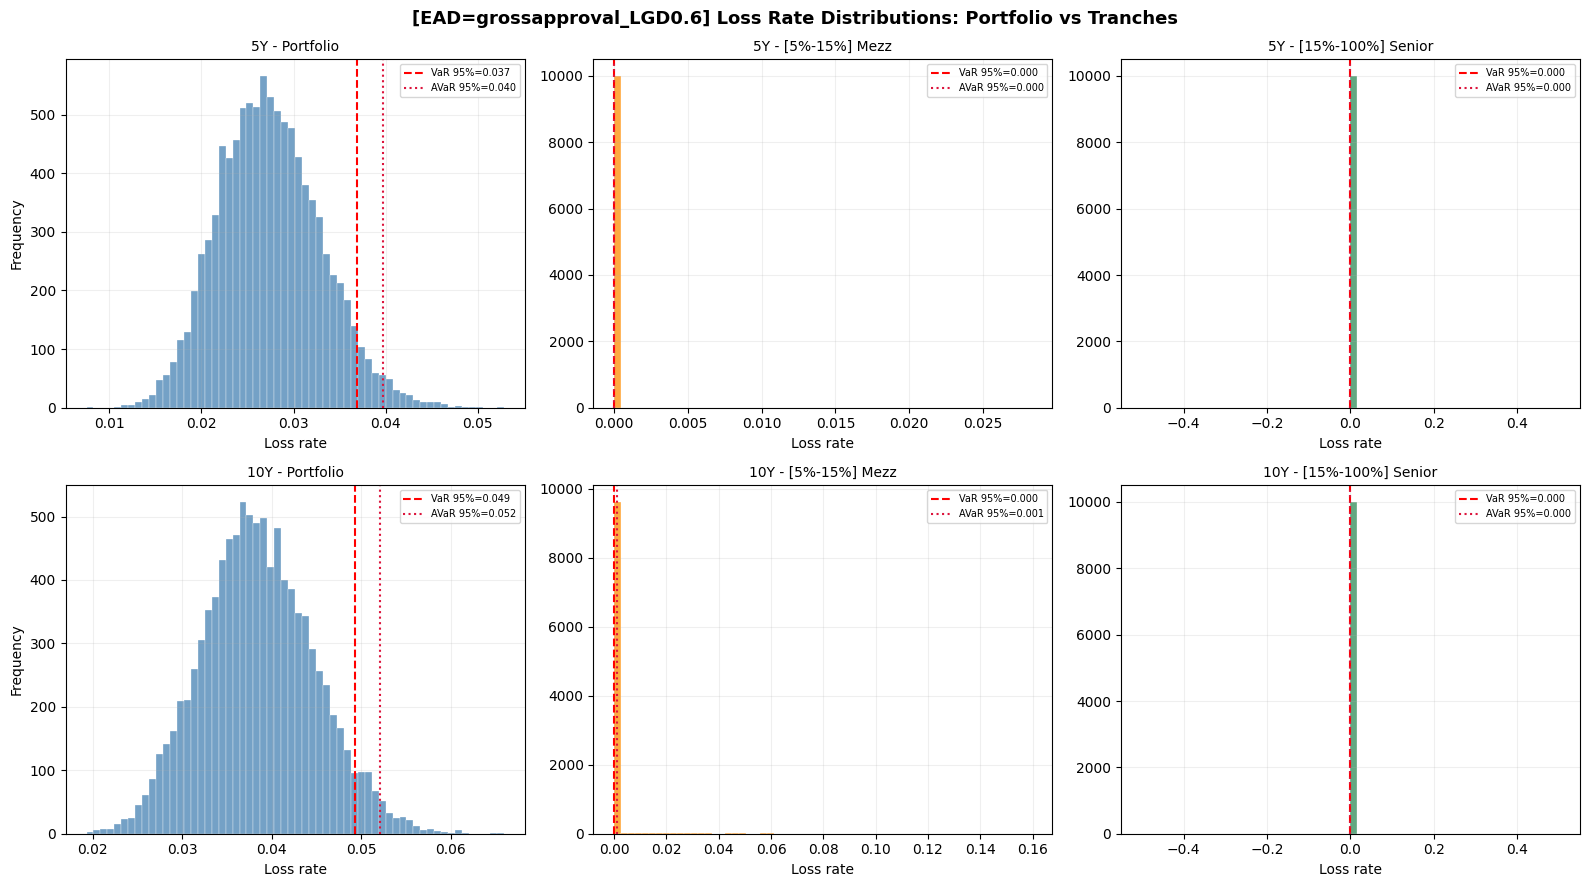

Saved: ../figures/tranche_distributions_EAD=grossapproval_LGD0.6.png


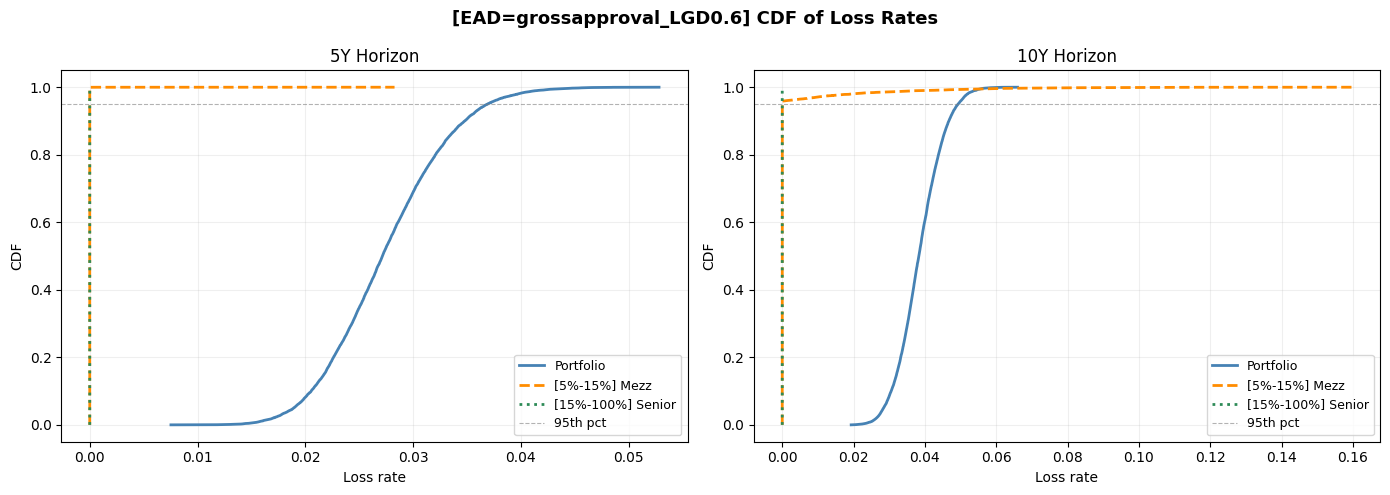

Saved: ../figures/tranche_cdf_EAD=grossapproval_LGD0.6.png


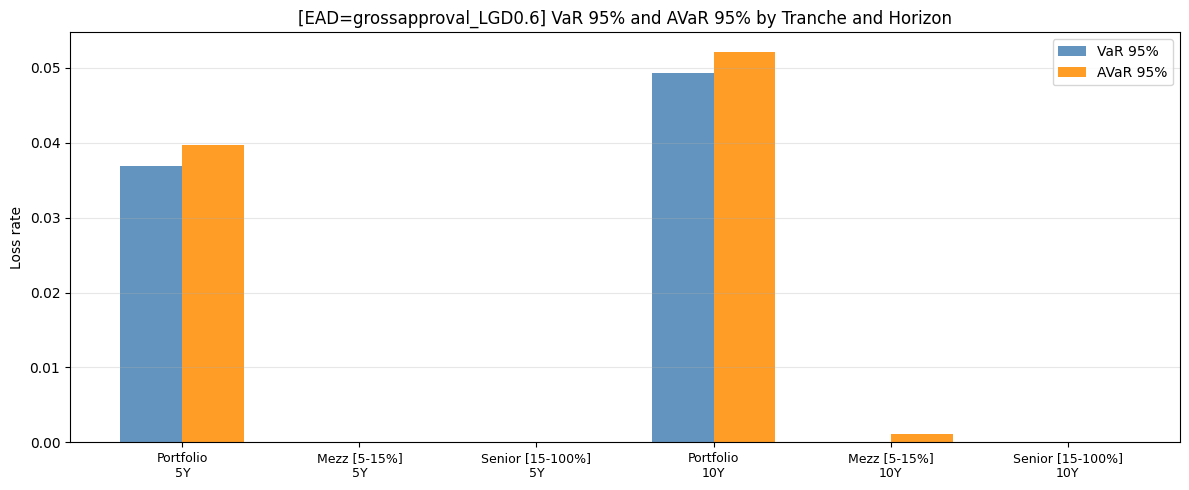

Saved: ../figures/tranche_var_comparison_EAD=grossapproval_LGD0.6.png


RISK METRICS SUMMARY  [EAD=grossapproval_LGD0.6]
                      Mean loss rate    Std  P(any loss)  P(wiped out)    P50    P90  VaR 95%  VaR 99%  AVaR 95%  AVaR 99%
Tranche / Horizon                                                                                                         
Portfolio 5Y                  0.0275 0.0056       1.0000        0.0000 0.0272 0.0348   0.0369   0.0415    0.0398    0.0440
Mezz [5-15%] 5Y               0.0000 0.0003       0.0002        0.0000 0.0000 0.0000   0.0000   0.0000    0.0000    0.0000
Senior [15-100%] 5Y           0.0000 0.0000       0.0000        0.0000 0.0000 0.0000   0.0000   0.0000   -0.0000   -0.0000
Portfolio 10Y                 0.0385 0.0063       1.0000        0.0000 0.0383 0.0467   0.0493   0.0539    0.0522    0.0563
Mezz [5-15%] 10Y              0.0011 0.0074       0.0412        0.0000 0.0000 0.0000   0.0000   0.0386    0.0011    0.0634
Senior [15-100%] 1

In [14]:
if __name__ == "__main__":
    main()